In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
!pip uninstall tensorflow -y

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB.zip to IMDB (1).zip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as ts

In [ ]:
df = pd.read_csv("/content/IMDB (1).zip")
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment'].values,
)

len(X_train), len(X_test)

(40000, 10000)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"Original y_train sample: {y_train[:5]}")
print(f"Encoded y_train sample: {y_train_encoded[:5]}")
print(f"Original y_test sample: {y_test[:5]}")
print(f"Encoded y_test sample: {y_test_encoded[:5]}")

Original y_train sample: ['positive' 'negative' 'negative' 'negative' 'negative']
Encoded y_train sample: [1 0 0 0 0]
Original y_test sample: ['negative' 'negative' 'positive' 'negative' 'negative']
Encoded y_test sample: [0 0 1 0 0]


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAXLEN = 200
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAXLEN, padding="post", truncating="post")

X_train_pad.shape, X_test_pad.shape

((40000, 200), (10000, 200))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

EMBED_DIM = 16

model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAXLEN),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!pip install keras

In [ ]:
history = model.fit(
    X_train_pad, y_train_encoded,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6958 - loss: 0.5926 - val_accuracy: 0.8173 - val_loss: 0.4377
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8406 - loss: 0.3904 - val_accuracy: 0.8581 - val_loss: 0.3365
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8762 - loss: 0.3210 - val_accuracy: 0.8766 - val_loss: 0.3052
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8922 - loss: 0.2906 - val_accuracy: 0.8730 - val_loss: 0.3037
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9072 - loss: 0.2588 - val_accuracy: 0.8823 - val_loss: 0.2932
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.2403 - val_accuracy: 0.8771 - val_loss: 0.3026
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9233 - loss: 0.2259 - val_accuracy: 0.8675 - val_loss: 0.3288


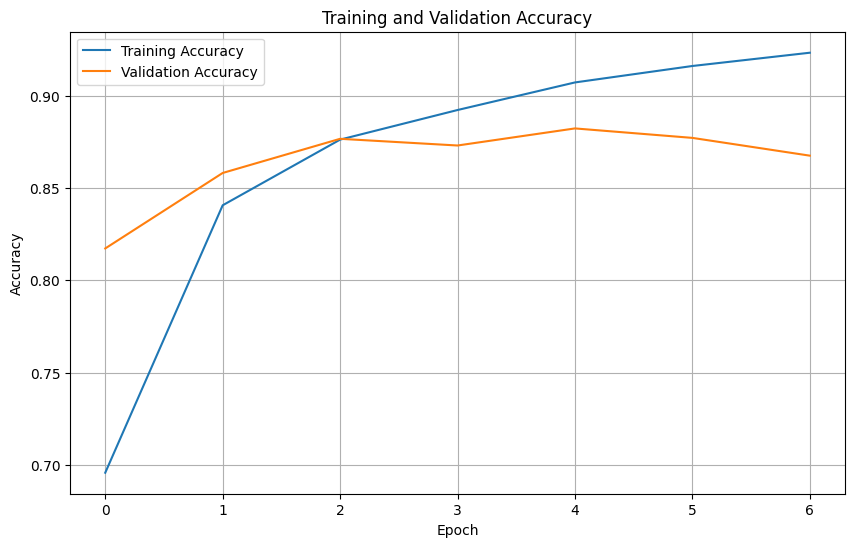

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8770 - loss: 0.2940
Test accuracy: 0.8770


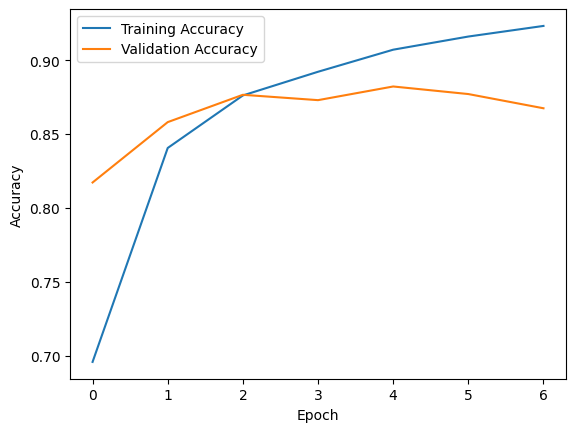

In [ ]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test_encoded)
print(f"Test accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import re
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    return text

samples = [
    "I loved every minute of this movie, the acting was superb.",
    "What a waste of time, the plot made no sense at all.",
    "It was okay, nothing special but not terrible either.",
]

samples_clean = [clean_text(s) for s in samples]
samples_seq = tokenizer.texts_to_sequences(samples_clean)
samples_pad = pad_sequences(samples_seq, maxlen=MAXLEN, padding="post", truncating="post")

preds = model.predict(samples_pad)
for text, score in zip(samples, preds):
    label = "positive" if score[0] >= 0.5 else "negative"
    print(f"{label:9s} ({score[0]:.2f})  {text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
positive  (0.71)  I loved every minute of this movie, the acting was superb.
negative  (0.08)  What a waste of time, the plot made no sense at all.
negative  (0.06)  It was okay, nothing special but not terrible either.


In [ ]:
import pickle
model.save("sentiment_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("saved sentiment_model.keras and tokenizer.pkl")


saved sentiment_model.keras and tokenizer.pkl


In [ ]:
from google.colab import files
files.download("sentiment_model.keras")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>